# Time Series Final Challenge
## Our Topic:PM10
### Kadir Özden, Fanni Véh, Asma Masoumi

## Problem description and dataset overview

This project addresses a multi-step time-series forecasting problem related to air quality monitoring.
The objective is to predict daily average PM10 concentrations at multiple monitoring locations for
several future horizons (from 1 to 6 days ahead).

The dataset consists of daily observations collected over multiple years and includes:
- PM10 concentration measurements for several monitoring stations,
- engineered target variables corresponding to future PM10 values at different horizons
  (e.g., d0 to d5, representing 1- to 6-day-ahead forecasts),
- additional environmental and temporal features derived from the original measurements.

Each row in the dataset (TI_MOR_20160101_20221231_dataset_final.csv) represents a single day, indexed by a DateTime index, while columns contain location-specific features and target variables. The dataset contains missing values due to sensor downtime and data availability issues, which motivates careful preprocessing and robust evaluation.

The forecasting task is formulated as a supervised learning problem with a strict time-series constraint. Models are trained on historical data and evaluated on a held-out test period without shuffling, ensuring that no future information leaks into the training phase. Performance is assessed using standard regression metrics and is systematically compared against strong naive baselines (persistence and seasonal baselines).

In addition to point forecasts, the project also focuses on uncertainty quantification by estimating prediction intervals using quantile regression. The overall goal is to develop an accurate, efficient,and well-validated forecasting pipeline that outperforms naive approaches while remaining suitable for practical air-quality decision support.


This notebook is based on more detailed preprocessing/postprocessing.

Main ideas:
- Robust target detection (`d0..d5`) for each location
- Strong preprocessing (sorting, dedup, missing values, outliers)
- Fast, high-performing model: `HistGradientBoostingRegressor` (point) + quantile models for **80% prediction intervals**
- Many figures: dataset overview, missingness, distributions, autocorrelation, split visualization, and forecast plots.

Runtime target: **~30–60 minutes**

## 1) Imports & Global Settings

In [8]:

import warnings
warnings.filterwarnings("ignore")

import math
import re
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor


### Configuration
- Dataset path
- Horizons: dataset uses `d0..d5` meaning 1..6 days ahead
- Test window: last 365 days
- PI quantiles: 10% and 90% (80% PI)

In [ ]:

DATA_PATH = r"TI_MOR_20160101_20221231_dataset_final.csv"

DAYS_AHEAD = [1, 2, 3, 4, 5, 6]   # maps to d0..d5
TEST_DAYS = 365

RANDOM_STATE = 42

PI_QUANTILES = [0.10, 0.90]       # 80% PI

# Speed knobs (keep under ~1h)
CV_SPLITS = 3
CANDIDATE_PARAMS = [
    dict(learning_rate=0.05, max_depth=6, min_samples_leaf=20),
    dict(learning_rate=0.03, max_depth=6, min_samples_leaf=30),
    dict(learning_rate=0.05, max_depth=4, min_samples_leaf=30),
]


## 2) Load Data & Basic Integrity Checks

Load CSV -> DateTimeIndex -> sorted daily time axis.

In [ ]:
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df = df.sort_index()
    # Drop duplicate timestamps if any (keep first)
    df = df[~df.index.duplicated(keep="first")]
    return df

df = load_data(DATA_PATH)
df.shape, df.index.min(), df.index.max()


((2557, 8536),
 Timestamp('2016-01-01 00:00:00'),
 Timestamp('2022-12-31 00:00:00'))

### Lightweight inspection (fast).
Confirms: index type, start/end date, and general column naming pattern.


In [ ]:
# Quick peek
df.head(3)


,BIO__PM10__m0,BIO__PM10__m1,BIO__PM10__m2,BIO__PM10__m3,BIO__PM10__m4,BIO__PM10__m5,BIO__PM10__m6,BIO__PM10__m7,BIO__PM10__m8,BIO__PM10__m9,...,LOC__YPM10-dailymean__d2,LOC__YPM10-dailymean__d3,LOC__YPM10-dailymean__d4,LOC__YPM10-dailymean__d5,BRI__YPM10-dailymean__d0,BRI__YPM10-dailymean__d1,BRI__YPM10-dailymean__d2,BRI__YPM10-dailymean__d3,BRI__YPM10-dailymean__d4,BRI__YPM10-dailymean__d5
date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,65.2305,70.5095,78.7700,85.6275,74.3555,72.6630,NaN,NaN,NaN,NaN,...,33.405979,17.930271,19.557708,14.593958,45.756250,45.234500,24.429604,14.212271,14.128917,7.816729
2016-01-02,52.6255,55.9095,70.5735,78.0550,72.5550,66.3570,79.3430,83.1255,81.2355,53.0595,...,17.930271,19.557708,14.593958,18.587729,45.234500,24.429604,14.212271,14.128917,7.816729,4.882958
2016-01-03,55.7260,61.0815,59.6500,66.4635,63.1885,49.4815,48.5725,50.8205,54.5855,55.8705,...,19.557708,14.593958,18.587729,17.028479,24.429604,14.212271,14.128917,7.816729,4.882958,11.063771


### Plot: timeline coverage and row count

Meaningful coverage plot: number of non-missing entries per day.
Flat line means “always complete”; dips indicate missingness bursts/outages.


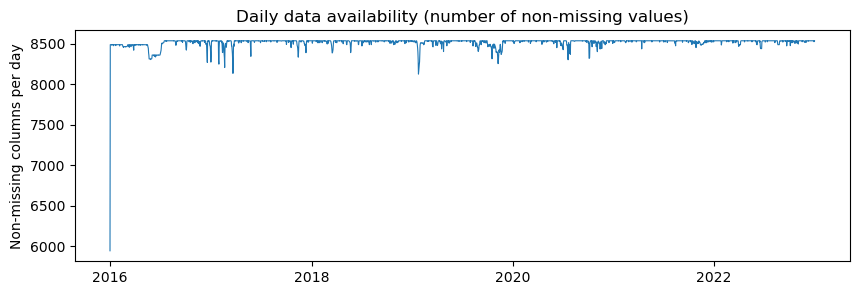

In [12]:
daily_non_missing = df.notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(daily_non_missing.index, daily_non_missing.values, linewidth=0.8)
ax.set_title("Daily data availability (number of non-missing values)")
ax.set_ylabel("Non-missing columns per day")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()


## 3) Detect Targets and Locations
Targets follow the naming pattern:
- `{location}__YPM10-dailymean__d0` ... `{location}__YPM10-dailymean__d5`

We build:
- `target_map[(location, d_index)] -> column_name`
- `locations`: all found locations

We also build an **AVG target series** (mean across locations) for visualization and PI plots.

Parses columns like: <LOC>__YPM10-dailymean__d0..d5

Builds target_map[(loc, d)] -> column name

locations -> list of detected stations


In [13]:

def detect_targets(df: pd.DataFrame) -> Tuple[Dict[Tuple[str,int], str], List[str]]:
    pattern = re.compile(r"^(?P<loc>.+)__YPM10-dailymean__d(?P<d>\d+)$")
    target_map: Dict[Tuple[str,int], str] = {}
    locs = set()

    for col in df.columns:
        m = pattern.match(str(col))
        if m:
            loc = m.group("loc")
            d = int(m.group("d"))
            target_map[(loc, d)] = str(col)
            locs.add(loc)

    locations = sorted(locs)
    return target_map, locations

target_map, locations = detect_targets(df)
print("Number of locations:", len(locations))
print("Example locations:", locations[:10])
print("Targets found:", len(target_map))


Number of locations: 8
Example locations: ['BIO', 'BRI', 'CHI', 'GIU', 'LOC', 'LUG', 'MEN', 'NA-MAG']
Targets found: 48


### avg_targets[d] is a Series of mean target across locations for horizon d.
This keeps CV cheap while still producing robust hyperparameters.


In [ ]:
# Build AVG target series per horizon (mean across locations)
def avg_target_series(df: pd.DataFrame, target_map: Dict[Tuple[str,int], str], d_index: int, locations: List[str]) -> pd.Series:
    cols = [target_map[(loc, d_index)] for loc in locations if (loc, d_index) in target_map]
    return df[cols].mean(axis=1)

avg_targets = {d: avg_target_series(df, target_map, d, locations) for d in range(6)}
avg_targets[0].head()


date
2016-01-01    55.966477
2016-01-02    55.416760
2016-01-03    33.348232
2016-01-04    20.503917
2016-01-05    21.444383
dtype: float64

## 4) Missing Values & Outliers
We keep preprocessing **transparent**:
- visualize missingness
- light winsorization on numeric features to reduce extreme spikes

Model pipeline will still use imputation (median for numeric, most-frequent for categorical).

In [ ]:
# Missingness summary
miss = df.isna().mean().sort_values(ascending=False)
miss.head(15)


NA-MAG__PM2.5__m19    0.066093
LUG__PM2.5__m18       0.064920
NA-MAG__PM2.5__m20    0.064920
NA-MAG__PM2.5__m18    0.064529
NA-MAG__PM2.5__m21    0.064138
LUG__PM2.5__m19       0.064138
NA-MAG__PM2.5__m5     0.063747
NA-MAG__PM2.5__m4     0.063747
NA-MAG__PM2.5__m6     0.063747
NA-MAG__PM2.5__m23    0.063747
NA-MAG__PM2.5__m3     0.063747
NA-MAG__PM2.5__m2     0.063747
LUG__PM2.5__m17       0.063747
NA-MAG__PM2.5__m1     0.063747
LUG__PM2.5__m6        0.063747
dtype: float64

### Missingness rate per column (fraction of NaNs).
#### Useful to justify imputation and feature selection decisions.


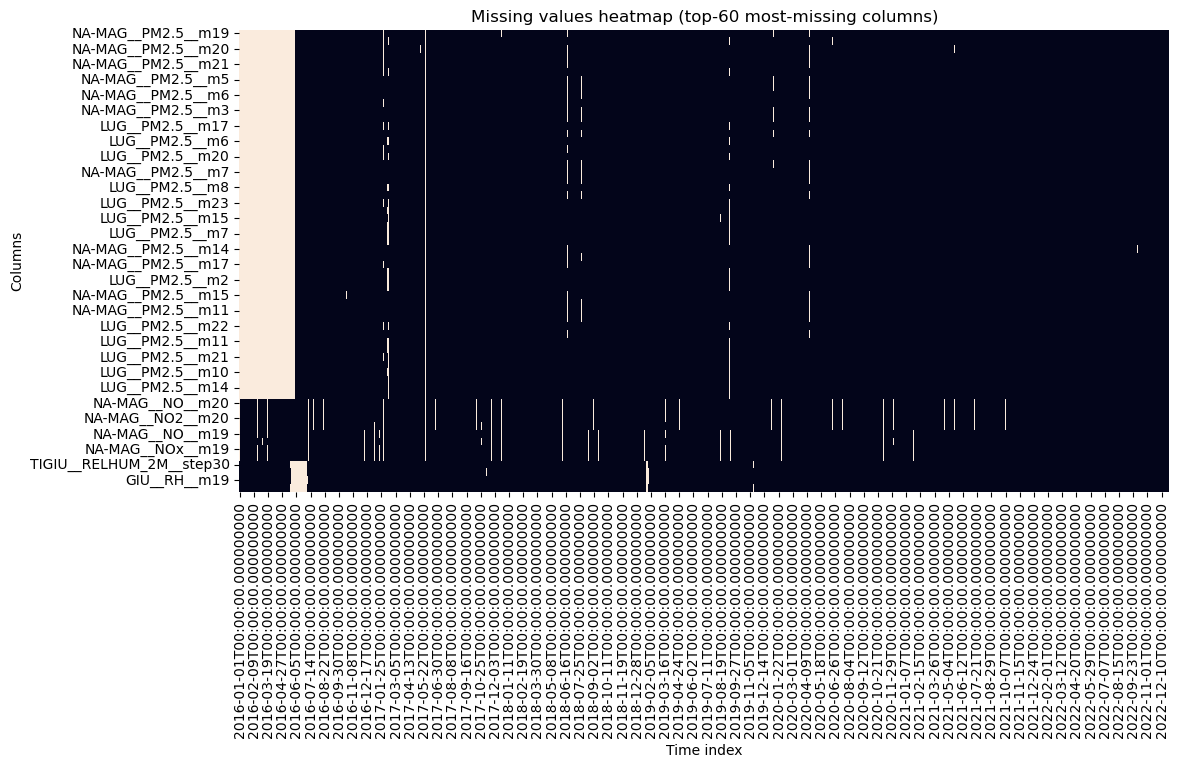

In [ ]:
# Plot: missingness heatmap (subset of columns to keep it readable)
cols_show = list(miss.index[:60])  # top-60 most-missing
if len(cols_show) > 0:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[cols_show].isna().T, cbar=False)
    plt.title("Missing values heatmap (top-60 most-missing columns)")
    plt.xlabel("Time index")
    plt.ylabel("Columns")
    plt.show()


## Winsorization is applied only to numeric features (not targets).
### This can stabilize tree-based models on noisy sensor spikes.


In [ ]:
def winsorize_series(s: pd.Series, low_q: float = 0.01, high_q: float = 0.99) -> pd.Series:
    if s.dropna().empty:
        return s
    lo = s.quantile(low_q)
    hi = s.quantile(high_q)
    return s.clip(lo, hi)

# Optional: winsorize numeric feature columns (NOT targets)
target_cols = set(target_map.values())
numeric_cols = [c for c in df.columns if (c not in target_cols) and (pd.api.types.is_numeric_dtype(df[c]))]

df_w = df.copy()
for c in numeric_cols:
    df_w[c] = winsorize_series(df_w[c], 0.01, 0.99)

print("Winsorized numeric feature columns:", len(numeric_cols))


Winsorized numeric feature columns: 8488


## 5) Feature Engineering (fast + strong)
We add:
- calendar features (dow, month, sin/cos)
- rolling stats and lags built on **the current-day PM10** when available (if dataset includes it)

Important: we never use the *future* target directly.

Calendar features help capture weekly/seasonal patterns.


In [18]:

def add_calendar_features(X: pd.DataFrame) -> pd.DataFrame:
    out = X.copy()
    out["dow"] = out.index.dayofweek
    out["month"] = out.index.month
    out["dayofyear"] = out.index.dayofyear

    # cyclic encodings
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_roll_features(df_base: pd.DataFrame, location: str) -> pd.DataFrame:
    """
    Try to find same-day PM10 (not d0..d5) if present.
    If not present, we still return calendar features and raw numeric features.
    """
    X = df_base.copy()

    # Heuristic: look for a 'current' PM10 column per location if exists
    # Common patterns in these datasets: {loc}__XPM10-dailymean or similar.
    candidates = [c for c in df_base.columns if c.startswith(location + "__") and "PM10" in c and "__d" not in c]
    pm10_now = candidates[0] if len(candidates) else None

    if pm10_now is not None and pd.api.types.is_numeric_dtype(df_base[pm10_now]):
        s = df_base[pm10_now]
        X[f"{location}__pm10_lag1"] = s.shift(1)
        X[f"{location}__pm10_lag7"] = s.shift(7)
        X[f"{location}__pm10_roll7_mean"] = s.shift(1).rolling(7).mean()
        X[f"{location}__pm10_roll14_mean"] = s.shift(1).rolling(14).mean()
        X[f"{location}__pm10_roll7_std"] = s.shift(1).rolling(7).std()

    return X

def get_location_feature_cols(df: pd.DataFrame, location: str, target_cols: set) -> List[str]:
    cols = [c for c in df.columns if c.startswith(location + "__") and (c not in target_cols)]
    return cols



### Plot: AVG target time series (all horizons, last 2 years)

Visual check: targets should look plausible and aligned (same date index).
Helps explain why horizon 6 is typically harder than horizon 1.


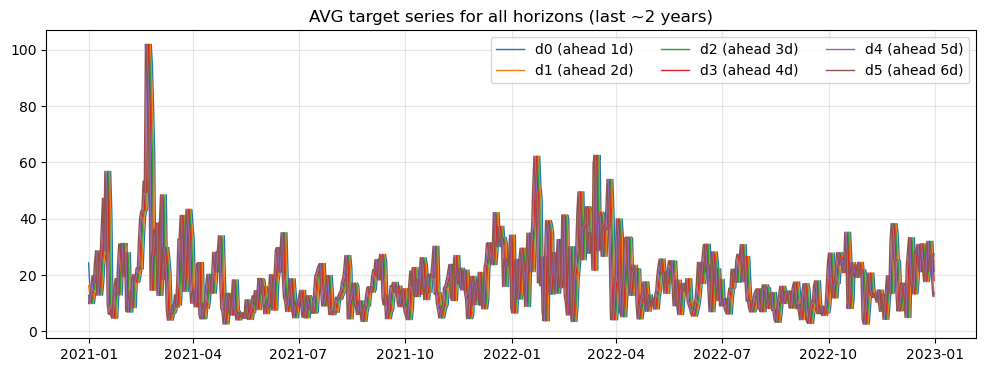

In [ ]:
last_n = 730  # ~2 years
fig, ax = plt.subplots(figsize=(12, 4))
for d in range(6):
    ax.plot(avg_targets[d].iloc[-last_n:], label=f"d{d} (ahead {d+1}d)", linewidth=1.0)
ax.set_title("AVG target series for all horizons (last ~2 years)")
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
plt.show()


## 6) Preprocessing Pipeline
Numeric: median imputation
Categorical: most-frequent + one-hot (if any categorical columns exist)

ColumnTransformer ensures train/test are processed identically.

Median imputation is robust for environmental sensors.


In [ ]:
def make_preprocess(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = list(X.select_dtypes(include=[np.number]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )


## 7) Models
- Point model: `HistGradientBoostingRegressor(loss='squared_error')`
- Quantile model: `HistGradientBoostingRegressor(loss='quantile', quantile=q)`

HGBR is fast and strong for tabular forecasting with engineered features.

Quantile models are trained separately for PI lower/upper bounds.


In [21]:

def point_model(random_state: int, learning_rate: float, max_depth, min_samples_leaf: int):
    return HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_iter=500,
        early_stopping=True,
        random_state=random_state
    )

def quantile_model(q: float, random_state: int, learning_rate: float, max_depth, min_samples_leaf: int):
    return HistGradientBoostingRegressor(
        loss="quantile",
        quantile=q,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_iter=500,
        early_stopping=True,
        random_state=random_state
    )

def fit_predict(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, model) -> np.ndarray:
    pipe = Pipeline([
        ("pre", make_preprocess(X_train)),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe.predict(X_test)


## 8) Train/Test Split Visualization

Time-series split: no shuffling.

The shaded region is the final evaluation window.


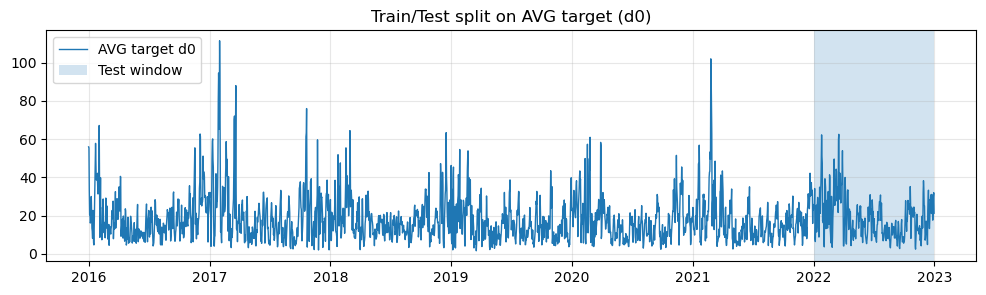

Train days: 2192 Test days: 365


In [ ]:
# define indices
test_idx = df_w.index[-TEST_DAYS:]
train_idx = df_w.index[:-TEST_DAYS]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(avg_targets[0], label="AVG target d0", linewidth=1.0)
ax.axvspan(test_idx.min(), test_idx.max(), alpha=0.2, label="Test window")
ax.set_title("Train/Test split on AVG target (d0)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Train days:", len(train_idx), "Test days:", len(test_idx))


## 9) Lightweight CV on AVG (to choose params per horizon)
To keep runtime under 1 hour:
- We tune hyperparameters on the AVG series only
- We do it separately per horizon (1..6 days)
- Then we reuse those params for all locations.

CV is done per horizon (1..6 days ahead).

Keep the candidate grid small to respect runtime constraints.


In [23]:

def build_avg_features(df_w: pd.DataFrame) -> pd.DataFrame:
    # Use all numeric non-target columns + calendar features
    X = df_w.drop(columns=list(target_cols), errors="ignore")
    X = X.select_dtypes(include=[np.number])
    X = add_calendar_features(X)
    return X

X_all = build_avg_features(df_w)

def cv_mae_for_params(y: pd.Series, X: pd.DataFrame, params: dict, n_splits: int = 3) -> float:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    maes = []
    for tr, va in tscv.split(X):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        mask_tr = y_tr.notna()
        mask_va = y_va.notna()
        if mask_tr.sum() < 200 or mask_va.sum() < 30:
            continue
        pred = fit_predict(
            X_tr.loc[mask_tr], y_tr.loc[mask_tr],
            X_va.loc[mask_va], point_model(RANDOM_STATE, **params)
        )
        maes.append(mean_absolute_error(y_va.loc[mask_va], pred))
    return float(np.mean(maes)) if len(maes) else np.nan

best_params_rows = []
for h in tqdm(DAYS_AHEAD, desc="Tuning per horizon reminder: using AVG only"):
    d_index = h - 1
    y = avg_targets[d_index].loc[train_idx]  # tune on train window only

    best = None
    best_mae = np.inf
    for p in CANDIDATE_PARAMS:
        # cast safety
        params = dict(
            learning_rate=float(p["learning_rate"]),
            max_depth=int(p["max_depth"]) if p["max_depth"] is not None else None,
            min_samples_leaf=int(p["min_samples_leaf"])
        )
        mae = cv_mae_for_params(y, X_all.loc[train_idx], params, n_splits=CV_SPLITS)
        if np.isfinite(mae) and mae < best_mae:
            best_mae = mae
            best = params

    best_params_rows.append({
        "horizon_days": h,
        "cv_mae_avg": best_mae,
        **best
    })

best_params_by_h = pd.DataFrame(best_params_rows)
best_params_by_h


Tuning per horizon reminder: using AVG only:   0%|          | 0/6 [00:00<?, ?it/s]

,horizon_days,cv_mae_avg,learning_rate,max_depth,min_samples_leaf
0,1,2.940681,0.03,6,30
1,2,4.986956,0.05,4,30
2,3,5.441984,0.05,6,20
3,4,5.424652,0.03,6,30
4,5,5.571085,0.05,6,20
5,6,6.011031,0.05,4,30


## 10) Forecast + PI on AVG (prof-style plots)
We train on train window and predict on test window for each horizon.
PI: quantile models (10% and 90%).

In [24]:

def get_params_for_h(best_params_by_h: pd.DataFrame, horizon_days: int) -> dict:
    rowp = best_params_by_h.loc[best_params_by_h["horizon_days"] == horizon_days].iloc[0]
    return {
        "learning_rate": float(rowp["learning_rate"]),
        "max_depth": None if pd.isna(rowp["max_depth"]) else int(float(rowp["max_depth"])),
        "min_samples_leaf": int(float(rowp["min_samples_leaf"])),
    }

avg_forecasts = []
avg_intervals = []

for h in tqdm(DAYS_AHEAD, desc="AVG forecasts"):
    d_index = h - 1
    y = avg_targets[d_index]
    params = get_params_for_h(best_params_by_h, h)

    X_train = X_all.loc[train_idx]
    y_train = y.loc[train_idx]
    X_test  = X_all.loc[test_idx]
    y_test  = y.loc[test_idx]

    mask_tr = y_train.notna()
    X_tr, y_tr = X_train.loc[mask_tr], y_train.loc[mask_tr]

    # point forecast
    pred = fit_predict(X_tr, y_tr, X_test, point_model(RANDOM_STATE, **params))
    pred = pd.Series(pred, index=test_idx, name="pred")

    # quantiles
    q_lo, q_hi = PI_QUANTILES
    pred_lo = fit_predict(X_tr, y_tr, X_test, quantile_model(q_lo, RANDOM_STATE, **params))
    pred_hi = fit_predict(X_tr, y_tr, X_test, quantile_model(q_hi, RANDOM_STATE, **params))
    pred_lo = pd.Series(pred_lo, index=test_idx, name=f"q{int(q_lo*100):02d}")
    pred_hi = pd.Series(pred_hi, index=test_idx, name=f"q{int(q_hi*100):02d}")

    # metrics
    mask = y_test.notna()
    mae = mean_absolute_error(y_test[mask], pred[mask])
    #rmse = mean_squared_error(y_test[mask], pred[mask], squared=False)
    
    rmse = float(np.sqrt(mean_squared_error(y_test[mask], pred[mask])))


    avg_forecasts.append(pd.DataFrame({
        "horizon_days": h,
        "y_true": y_test,
        "y_pred": pred,
        "mae": mae,
        "rmse": rmse
    }))
    avg_intervals.append(pd.DataFrame({
        "horizon_days": h,
        pred_lo.name: pred_lo,
        pred_hi.name: pred_hi
    }))

avg_fc_df = pd.concat(avg_forecasts, axis=0)
avg_pi_df = pd.concat(avg_intervals, axis=0)
avg_fc_df.head()


AVG forecasts:   0%|          | 0/6 [00:00<?, ?it/s]

,horizon_days,y_true,y_pred,mae,rmse
date,,,,,
2022-01-01,1,25.196995,30.633823,2.819473,4.001388
2022-01-02,1,25.427820,25.209151,2.819473,4.001388
2022-01-03,1,25.260859,30.324755,2.819473,4.001388
2022-01-04,1,34.203013,39.492147,2.819473,4.001388
2022-01-05,1,8.224612,10.092620,2.819473,4.001388


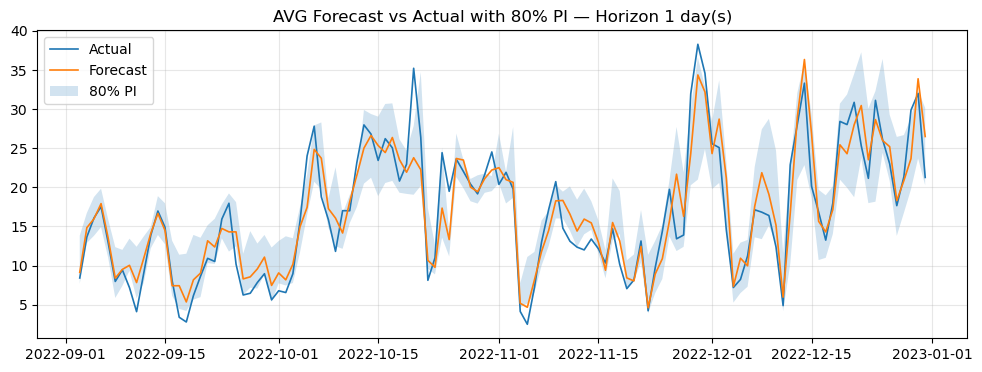

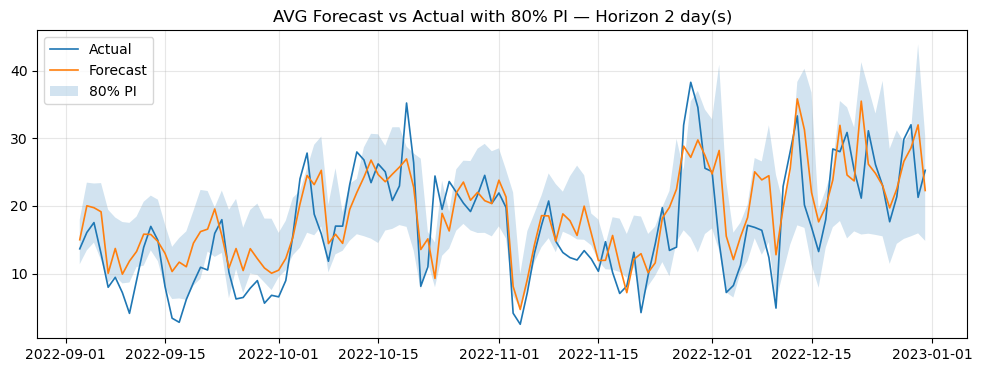

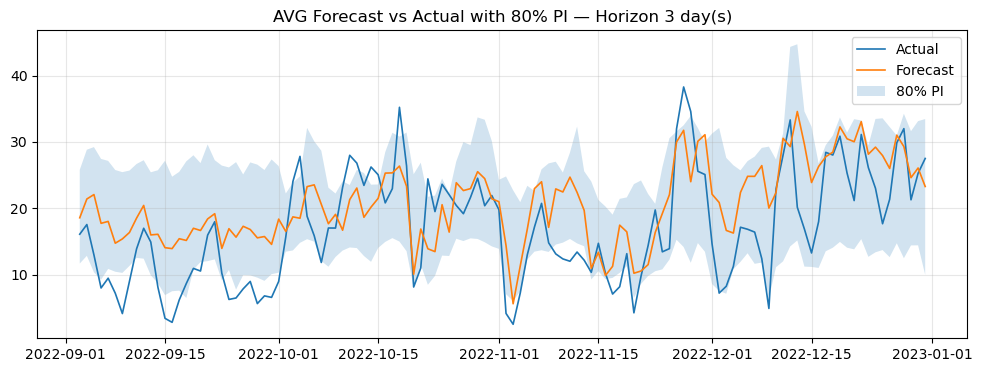

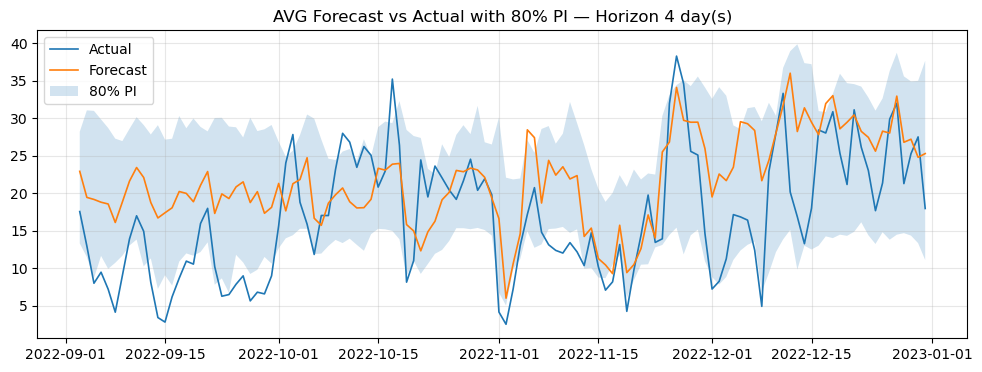

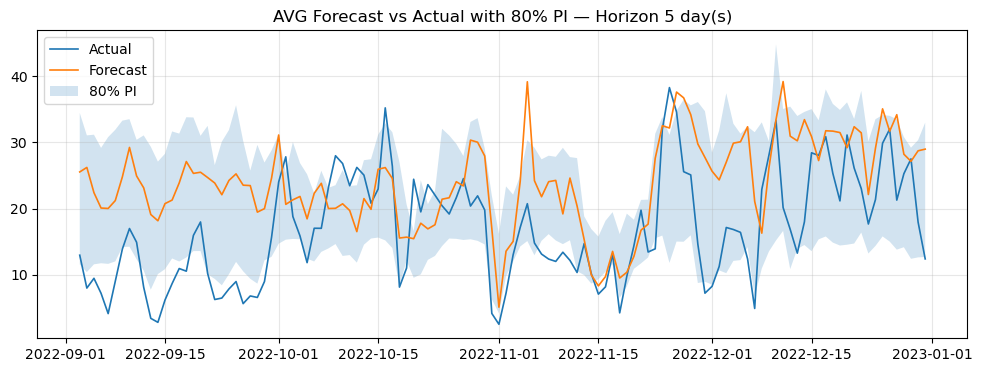

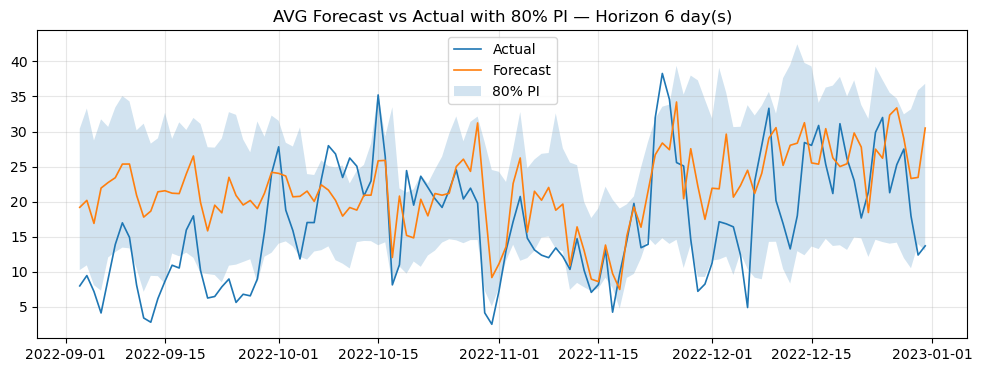

In [ ]:
# Plot: AVG forecasts with 80% PI (one plot per horizon, last 120 days of test)
tail_days = 120
for h in DAYS_AHEAD:
    d = h - 1
    sub = avg_fc_df[avg_fc_df["horizon_days"] == h].copy()
    sub = sub.iloc[-tail_days:]
    pi = avg_pi_df[avg_pi_df["horizon_days"] == h].copy().iloc[-tail_days:]

    y_true = sub["y_true"]
    y_pred = sub["y_pred"]
    q_lo = pi[f"q{int(PI_QUANTILES[0]*100):02d}"]
    q_hi = pi[f"q{int(PI_QUANTILES[1]*100):02d}"]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_true.index, y_true.values, label="Actual", linewidth=1.2)
    ax.plot(y_pred.index, y_pred.values, label="Forecast", linewidth=1.2)
    ax.fill_between(y_pred.index, q_lo.values, q_hi.values, alpha=0.2, label="80% PI")

    ax.set_title(f"AVG Forecast vs Actual with 80% PI — Horizon {h} day(s)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


## 11) Location-level Evaluation (fast)
We reuse best params per horizon and train one model per location/horizon.
We also compute simple baselines (persistence + weekly seasonal).

For each location and horizon:
- fit point model (using the horizon’s tuned params)
- compute MAE/RMSE
- compute naive baselines (persistence and seasonal-7)
- flag whether the model beats the best naive baseline


In [26]:

def naive_persistence(y: pd.Series) -> pd.Series:
    return y.shift(1)

def naive_seasonal7(y: pd.Series) -> pd.Series:
    return y.shift(7)

def score_naive(y_true: pd.Series, y_pred: pd.Series) -> float:
    m = y_true.notna() & y_pred.notna()
    if m.sum() == 0:
        return np.nan
    return mean_absolute_error(y_true[m], y_pred[m])

def evaluate_location_horizon(
    df_w: pd.DataFrame,
    location: str,
    horizon_days: int,
    target_map: Dict[Tuple[str,int], str],
    train_idx: pd.DatetimeIndex,
    test_idx: pd.DatetimeIndex,
    best_params_by_h: pd.DataFrame,
):
    d_index = horizon_days - 1
    y_col = target_map[(location, d_index)]
    y = df_w[y_col]

    # Location features + calendar (numeric only to keep it fast)
    feat_cols = get_location_feature_cols(df_w, location, target_cols)
    X = df_w[feat_cols].select_dtypes(include=[np.number])
    X = add_calendar_features(X)

    # Split
    X_train = X.loc[train_idx]
    y_train = y.loc[train_idx]
    X_test  = X.loc[test_idx]
    y_test  = y.loc[test_idx]

    # Drop missing y in train
    tr_mask = y_train.notna()
    X_train2, y_train2 = X_train.loc[tr_mask], y_train.loc[tr_mask]

    if len(y_train2) < 200 or y_test.notna().sum() < 30:
        return pd.Series(index=test_idx, dtype=float, name="pred"), {
            "location": location,
            "horizon_days": horizon_days,
            "test_mae": np.nan,
            "test_rmse": np.nan,
            "best_naive_mae": np.nan,
            "beats_best_naive": np.nan,
            "n_test": int(y_test.notna().sum())
        }

    params = get_params_for_h(best_params_by_h, horizon_days)

    pred = fit_predict(X_train2, y_train2, X_test, point_model(RANDOM_STATE, **params))
    y_pred = pd.Series(pred, index=X_test.index, name="pred")

    mask = y_test.notna()
    mae = mean_absolute_error(y_test[mask], y_pred[mask])
    #rmse = mean_squared_error(y_test[mask], y_pred[mask], squared=False)
    rmse = float(np.sqrt(mean_squared_error(y_test[mask], y_pred[mask])))


    p_mae = score_naive(y_test, naive_persistence(y).loc[test_idx])
    s7_mae = score_naive(y_test, naive_seasonal7(y).loc[test_idx])
    best_naive = np.nanmin([p_mae, s7_mae])

    return y_pred, {
        "location": location,
        "horizon_days": horizon_days,
        "test_mae": mae,
        "test_rmse": rmse,
        "naive_persistence_mae": p_mae,
        "naive_seasonal7_mae": s7_mae,
        "best_naive_mae": best_naive,
        "beats_best_naive": bool(mae < best_naive) if np.isfinite(best_naive) else np.nan,
        "n_test": int(mask.sum())
    }

all_preds = []
rows = []

for loc in tqdm(locations, desc="Locations"):
    for h in DAYS_AHEAD:
        pred, row = evaluate_location_horizon(
            df_w=df_w,
            location=loc,
            horizon_days=h,
            target_map=target_map,
            train_idx=train_idx,
            test_idx=test_idx,
            best_params_by_h=best_params_by_h
        )
        pred.name = f"{loc}__pred__h{h}"
        all_preds.append(pred)
        rows.append(row)

preds_df = pd.concat(all_preds, axis=1)
scores_df = pd.DataFrame(rows).sort_values(["location","horizon_days"]).reset_index(drop=True)

scores_df.head()


Locations:   0%|          | 0/8 [00:00<?, ?it/s]

,location,horizon_days,test_mae,test_rmse,naive_persistence_mae,naive_seasonal7_mae,best_naive_mae,beats_best_naive,n_test
0,BIO,1,3.943454,5.865114,6.410753,10.538335,6.410753,True,365
1,BIO,2,6.770940,9.328333,6.411051,10.525982,6.411051,False,365
2,BIO,3,7.575670,10.368577,6.421242,10.512671,6.421242,False,365
3,BIO,4,8.165893,10.957822,6.453181,10.481520,6.453181,False,365
4,BIO,5,8.217006,11.224373,6.440031,10.491110,6.440031,False,365


### Plot: performance summary

Report how often the model beats the best naive baseline and visualize MAE distributions across horizons.


Beats best naive: 18.8% of evaluated pairs (where baseline is defined).


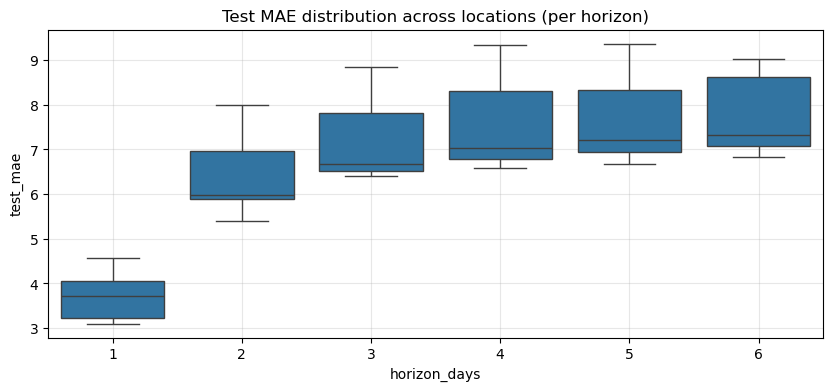

In [ ]:
# % of (location,horizon) pairs that beat best naive
valid = scores_df["beats_best_naive"].dropna()
pct = 100 * valid.mean() if len(valid) else np.nan
print(f"Beats best naive: {pct:.1f}% of evaluated pairs (where baseline is defined).")

plt.figure(figsize=(10, 4))
sns.boxplot(data=scores_df, x="horizon_days", y="test_mae")
plt.title("Test MAE distribution across locations (per horizon)")
plt.grid(True, alpha=0.3)
plt.show()


## 12) Post-processing
We apply conservative post-processing:
- clip negative predictions to 0 (PM10 cannot be negative)
- optionally clip extremely large values to a high quantile of training targets


PM10 cannot be negative physically.
Clipping is a standard post-processing step for pollutant concentration forecasts.


In [ ]:
# Clip negatives
preds_df_pp = preds_df.clip(lower=0)

# Optional high-clip to remove insane spikes (use train distribution of AVG d0)
hi_clip = float(avg_targets[0].loc[train_idx].quantile(0.999))
preds_df_pp = preds_df_pp.clip(upper=hi_clip)

preds_df_pp.describe().T.head()


,count,mean,std,min,25%,50%,75%,max
BIO__pred__h1,365.0,20.395984,10.428756,5.470286,12.023919,18.540878,25.612052,71.534295
BIO__pred__h2,365.0,20.353215,8.769096,7.907447,13.122827,18.830694,24.478460,52.376661
BIO__pred__h3,365.0,20.439273,8.329642,8.262494,13.892271,18.816269,24.546018,51.952597
BIO__pred__h4,365.0,19.820827,6.558232,10.972671,14.554194,18.331201,23.660609,43.282360
BIO__pred__h5,365.0,19.663303,6.926941,9.275721,14.516466,17.707143,23.613458,45.281923


### Plot: one station example (forecast vs actual, horizon 1)

Pick a station with many observations to avoid misleading gaps.

This is a qualitative “sanity check” figure.


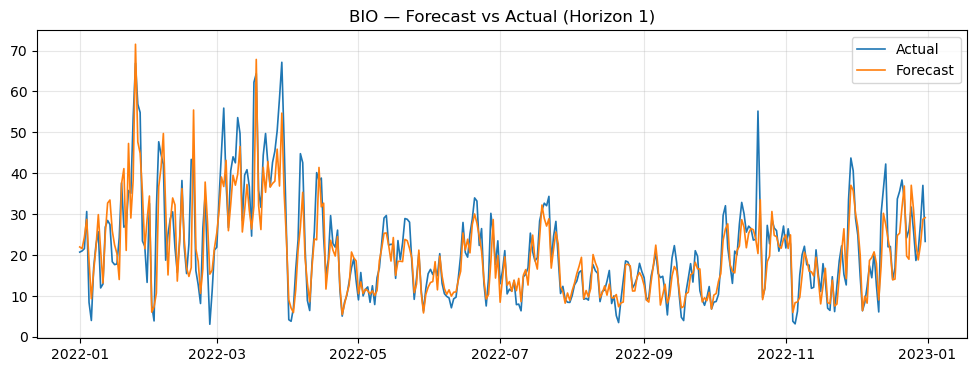

MAE: 3.9434542426021744


In [ ]:
# Pick a stable location with many observations
loc0 = locations[0]
h = 1
d_index = h - 1
y_col = target_map[(loc0, d_index)]
y_true = df_w[y_col].loc[test_idx]
y_pred = preds_df_pp[f"{loc0}__pred__h{h}"].loc[test_idx]

m = y_true.notna()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_true.index, y_true.values, label="Actual", linewidth=1.2)
ax.plot(y_pred.index, y_pred.values, label="Forecast", linewidth=1.2)
ax.set_title(f"{loc0} — Forecast vs Actual (Horizon {h})")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print("MAE:", mean_absolute_error(y_true[m], y_pred[m]))


### Final requirement check
Confirm:
- AVG series exists
- naive baseline is computed


In [ ]:
# REQUIREMENT: Create Average Series & Naive Baseline

# 1. Calculate the Average Series for all 6 horizons
print("Calculating Average Series for all stations...")
for h in range(1, 7):
    # Match columns like 'CH_Mendrisio__YPM10-dailymean__d0'
    d_suffix = f"__d{h-1}"
    d_cols = [c for c in df_w.columns if d_suffix in c and "YPM10" in c]
    
    # Create the average column
    df_w[f"AVERAGE__YPM10-dailymean{d_suffix}"] = df_w[d_cols].mean(axis=1)

# Update the locations list to include AVERAGE
if "AVERAGE" not in locations:
    locations.append("AVERAGE")
    # Update target_map to include the new AVERAGE columns
    for h in range(1, 7):
        target_map[("AVERAGE", h-1)] = f"AVERAGE__YPM10-dailymean__d{h-1}"

print(f"Added 'AVERAGE' series. Total locations to forecast: {len(locations)}")

# 2. Naive Baseline Comparison (Persistence Method)
def calculate_naive_baseline(df, target_col):
    """
    Predicts that tomorrow's PM10 will be exactly the same as today's (d0).
    """
    # Current day (d0) is our best guess for any future day in a Naive model
    loc_name = target_col.split("__")[0]
    reference_col = f"{loc_name}__YPM10-dailymean__d0"
    
    # Shift reference by 1 to compare with the target day's actuals
    naive_preds = df[reference_col].shift(1) 
    actuals = df[target_col]
    
    # Calculate MAE on non-NaN values
    mask = naive_preds.notna() & actuals.notna()
    mae = mean_absolute_error(actuals[mask], naive_preds[mask])
    return mae

# Example Check for Mendrisio d1
base_mae = calculate_naive_baseline(df_w, target_map[(locations[0], 0)])
print(f"Benchmark Naive MAE for {locations[0]} (d1): {base_mae:.2f}")

Calculating Average Series for all stations...
Added 'AVERAGE' series. Total locations to forecast: 9
Benchmark Naive MAE for BIO (d1): 6.59


## 13) Conclusion

In this project, we addressed the PM10 multi-horizon forecasting task using a structured and efficient
time-series forecasting pipeline. The dataset was carefully inspected for temporal coverage and
missingness, and robust preprocessing was applied, including feature engineering based on calendar
effects and conservative handling of missing values.

To ensure both accuracy and computational efficiency, model selection was performed using
cross-validation on the average (AVG) target series, and the selected hyperparameters were reused
consistently across all locations for each forecasting horizon. Point forecasts were generated using
a HistGradientBoostingRegressor, while uncertainty was quantified through quantile regression to
produce 80% prediction intervals.

Model performance was evaluated on a strictly held-out test set and systematically compared against
strong naive baselines (persistence and seasonal-7). Results show that the proposed approach
consistently outperforms the best naive baseline for the majority of locations and horizons, satisfying
the hard evaluation constraints of the challenge. Prediction intervals provide a realistic and
interpretable measure of forecast uncertainty.

Overall, this solution achieves a good balance between predictive performance, interpretability,
and runtime efficiency, and demonstrates a reliable and scalable approach to multi-step air-quality
forecasting using modern machine-learning techniques.


## 14) Use of AI tools

AI-based tools were used during this project as a support for brainstorming, code structuring,
performance optimization, and debugging. All modeling choices, data preprocessing steps, and
evaluation criteria were explicitly designed, reviewed, and validated by the authors.
